# Streamlit, ngrok 설치

In [29]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

### 조건 1 데이터 준비, 샘플링

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split

data_url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
raw_data = pd.read_csv(data_url)

#Schooling은 빼고, 기대수명(Life expectancy) 맞추기 위해 변수 3개 고르기
#Adult Mortality, BMI, GDP선택
target = 'Life expectancy'
my_features = ['Adult mortality', 'BMI', 'GDP']

#결측치 제거하기
ndf = raw_data.dropna(subset=[target] + my_features)
X = ndf[my_features]
y = ndf[target]

# 80대 20비율로 훈련용, 테스트용 세트 쪼개기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#50개 무작위 추출
X_train_sub = X_train.sample(n=50, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index]

### 조건 2 모델 3종 학습, 저장

In [70]:
import joblib # 학습된 모델 및 데이터를 파일로 저장/로드
from sklearn.pipeline import Pipeline # 데이터 전처리와 모델 학습 과정을 하나로 묶어주는 파이프라인
from sklearn.preprocessing import StandardScaler, PolynomialFeatures  # 데이터의 특성(Feature) 스케일을 평균 0, 분산 1로 맞추는 표준화 도구
from sklearn.linear_model import LinearRegression, Ridge # 선형 분류 알고리즘인 로지스틱 회귀 모델
from sklearn.metrics import mean_squared_error, r2_score

#파이프라인 리스트 구조
#기본 선형, 3차 다항회귀, 3차 다항회귀+릿지규제 순서
my_models = [
    ('Linear', Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])),
    ('Poly', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)), #degree 3
        ('reg', LinearRegression())
    ])),
    ('Ridge', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3)), #degree 3
        ('reg', Ridge(alpha=1.0)) #alpha 1.0
    ]))
]

#결과값리스트
results = []

#50개짜리 작은 샘플로 학습시키고 스코어 뽑기
for name, model in my_models:
    model.fit(X_train_sub, y_train_sub)

    # 예측값
    pred_train = model.predict(X_train_sub)
    pred_test = model.predict(X_test)

    #차원 변환 후 최종 특성 개수(Complexity)
    if 'poly' in model.named_steps:
        comp = model.named_steps['poly'].transform(X_train_sub[:1]).shape[1]
    else:
        comp = X_train_sub.shape[1] + 1

    # 결정계수(R2), MSE 평가점수
    r2_tr, r2_te = r2_score(y_train_sub, pred_train), r2_score(y_test, pred_test)
    mse_tr, mse_te = mean_squared_error(y_train_sub, pred_train), mean_squared_error(y_test, pred_test)

    #딕셔너리
    results.append({
        'Model': name,
        'Complexity': comp,
        'Train R2': r2_tr,
        'Train MSE': mse_tr,
        'Test R2': r2_te,
        'Test MSE': mse_te
    })

    #pkl 파일로 저장
    joblib.dump(model, f'model_{name.lower()}.pkl')

# 데이터프레임
df_res = pd.DataFrame(results)
joblib.dump(df_res, 'metrics.pkl')
print(".pkl 파일 저장")

.pkl 파일 저장


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


### 조건 3 성능 비교 화면 구현

데이터프레임 테이블 미리보기


,Model,Complexity,Train R2,Train MSE,Test R2,Test MSE
0,Linear,4,0.687597,30.736230,0.604048,35.786527
1,Poly,20,0.938053,6.094772,-4.216511,471.473691
2,Ridge,20,0.910692,8.786714,-0.305665,118.007387


/tmp/ipykernel_15266/321797870.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test R2', data=df_res, palette='pastel')
/tmp/ipykernel_15266/321797870.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


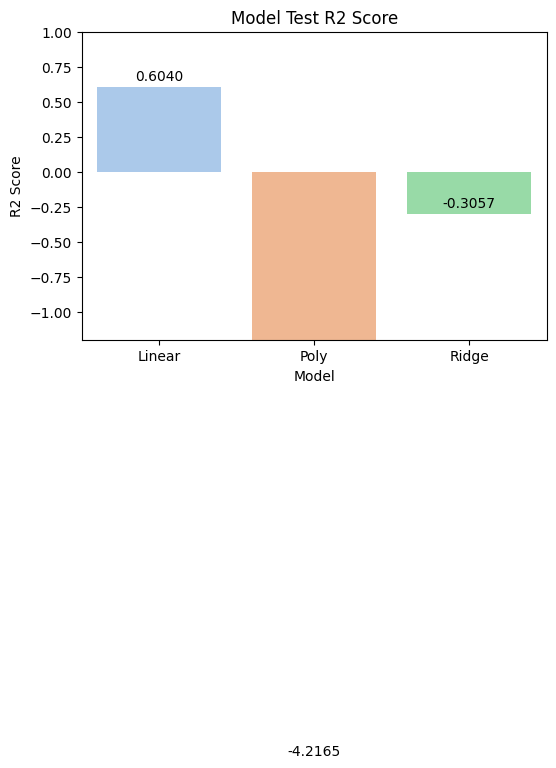

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

#아까 만든 데이터프레임 가져오기
df_res = joblib.load('metrics.pkl')

print("데이터프레임 테이블 미리보기")
display(df_res)

# 웹에 올리기 전에 대략 그래프 그려보기
plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Test R2', data=df_res, palette='pastel')
plt.title("Model Test R2 Score")
plt.ylabel("R2 Score")
plt.ylim(-1.2, 1.0)

# 막대기에 스코어
for i in range(len(df_res)):
    score = df_res.loc[i, 'Test R2']
    plt.text(i, score + 0.05, f"{score:.4f}", ha='center', fontsize=10) #4자리까지만

plt.tight_layout()
plt.show()

### 조건 4 웹 서비스 구현

In [72]:
%%writefile app.py
# 라이브러리 임포트: 웹 UI, 수치 연산, 모델 로드, 데이터 가공을 위한 핵심 패키지들
import streamlit as st # Streamlit 웹 어플리케이션 제작
import pandas as pd  # 표 형태의 데이터를 다루고 테이블 UI를 생성
import numpy as np # 다차원 배열 연산 및 데이터 형태 변환
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # 학습된 머신러닝 모델(.pkl 파일)을 디스크에서 불러오기

st.set_page_config(page_title="기대수명 예측 프로그램", layout="wide")
st.title("WHO 기대수명 분석 및 예측 대시보드")

try:
    m_linear = joblib.load('model_linear.pkl')
    m_poly = joblib.load('model_poly.pkl')
    m_ridge = joblib.load('model_ridge.pkl')
    df_res = joblib.load('metrics.pkl')
except:  # 만약 해당 경로에 파일이 없다면 사용자에게 경고 메시지를 출력
    st.error("⚠️ 'dog_classifier_models.pkl' 파일이 존재하지 않습니다. 먼저 모델 학습 코드를 실행해 주세요!")
    st.stop()

#사이드바 서브메뉴
st.sidebar.markdown("대시보드 메뉴")
choice = st.sidebar.radio("원하는 화면 선택 :", ["1. 모델 성능 평가 비교", "2. 실시간 수명 예측 UI"])

# 1번 화면: 표랑 막대그래프 출력 섹션
if choice == "1. 모델 성능 평가 비교":
    st.subheader("3종 회귀분석 파이프라인 결과 성능 지표")
    st.markdown("Adult Mortality, BMI, GDP")

    # 판다스 테이블
    st.dataframe(df_res)

    # Matplotlib 막대그래프
    st.subheader("결정 계수Test R2 Score 비교 시각화")
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    sns.barplot(x='Model', y='Test R2', data=df_res, ax=ax, palette='pastel')
    ax.set_ylim(-1.2, 1.0)

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=9)
    st.pyplot(fig)

# 2번 화면: 슬라이더 화면
elif choice == "2. 실시간 수명 예측 UI":
    st.subheader("사용자 맞춤 수치 입력 및 예측")
    st.write("슬라이더를 움직여서 관측")

    left_col, right_col = st.columns([1, 1.5])

    with left_col:
        st.markdown("독립변수 설정")
        v_mortality = st.slider("성인 사망률 (Adult Mortality)", 1, 700, 140, 1)
        v_bmi = st.slider("체질량지수 (BMI)", 1.0, 80.0, 38.0, 0.1)
        v_gdp = st.slider("국내총생산 (GDP)", 1, 95000, 5500, 100)

        user_model = st.selectbox("예측 알고리즘 선택:", ["Linear", "Poly", "Ridge"])

    with right_col:
        st.markdown("실시간 연산 출력")

        input_data = np.array([[v_mortality, v_bmi, v_gdp]])

        if user_model == "Linear":
            fit_model = m_linear
        elif user_model == "Poly":
            fit_model = m_poly
        else:
            fit_model = m_ridge

        #넘파이 배열로 예측
        pred_y = fit_model.predict(input_data)[0]

        if pred_y < 0:
            st.error(f"예측 수명이 {pred_y:.2f}세(음수)로 도출되었습니다. "
                     f"규제가 없는 3차 다항회귀(Poly) 모델이 특정 데이터 구간에서 과대적합되어 나타나는 현상입니다. "
                     f"슬라이더 값을 평균치로 바꾸거나, 규제가 포함된 모델을 골라주세요.")
        else:
            st.metric(label=f"[{user_model}] 모델 기반 최종 예상 수명", value=f"{pred_y:.2f} 세")
            st.progress(int(np.clip(pred_y, 0, 100)))

            if pred_y >= 75:
                st.success("높은 기대수명")
            elif pred_y >= 60:
                st.info("평균 기대수명")
            else:
                st.warning("위험 수치")

Overwriting app.py


### 조건 5 ngrok 서비스 배포

In [73]:
!pip install streamlit pyngrok --q
from pyngrok import ngrok
import os

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정 (여기에 본인의 토큰을 붙이기)
ngrok.set_auth_token("3Dw21pCMXcGAZp0BDJfqL1esIVk_XgDbqjneyE4f6Mp5snDd")

# 3. Streamlit 실행
os.system("nohup streamlit run app.py --server.port 8501 &")

# 4. ngrok 터널 연결
web_link = ngrok.connect(8501, bind_tls=True)

print("링크:", web_link)

링크: NgrokTunnel: "https://retention-clapper-grower.ngrok-free.dev" -> "http://localhost:8501"


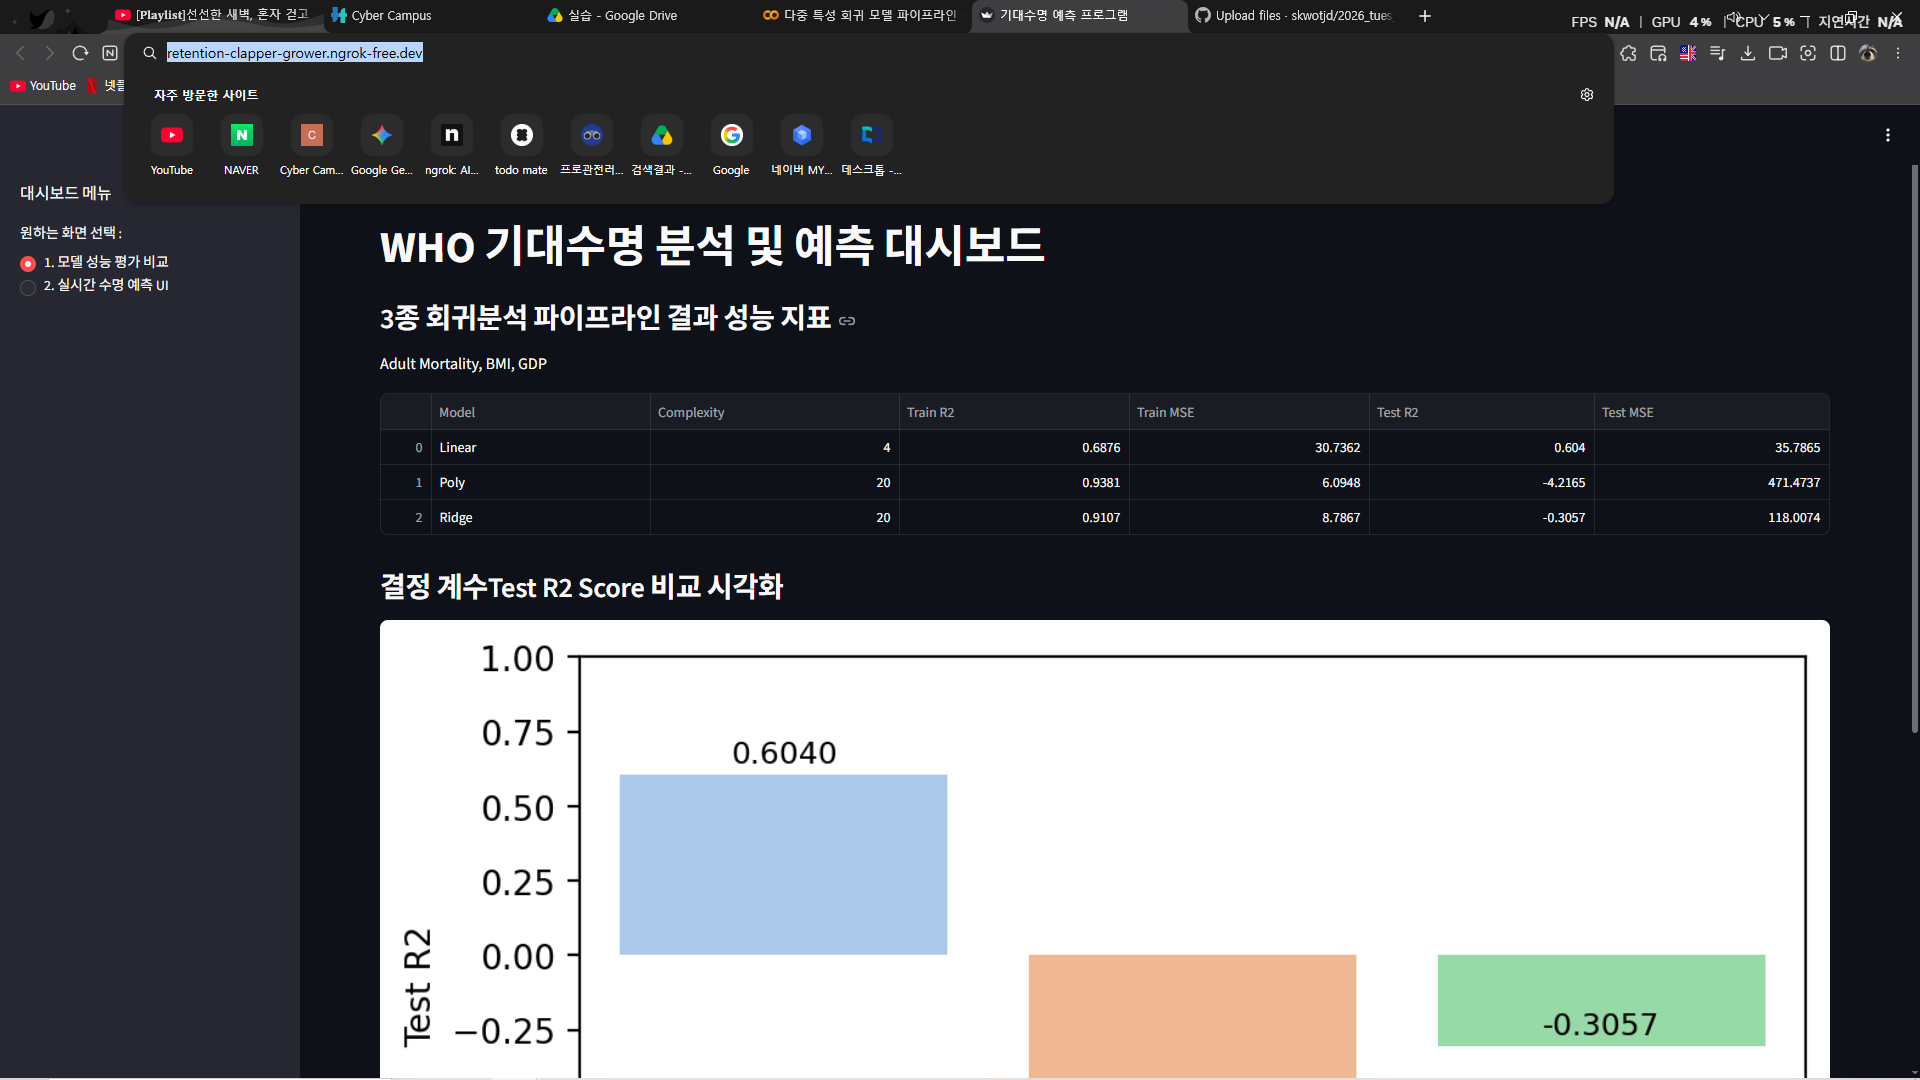

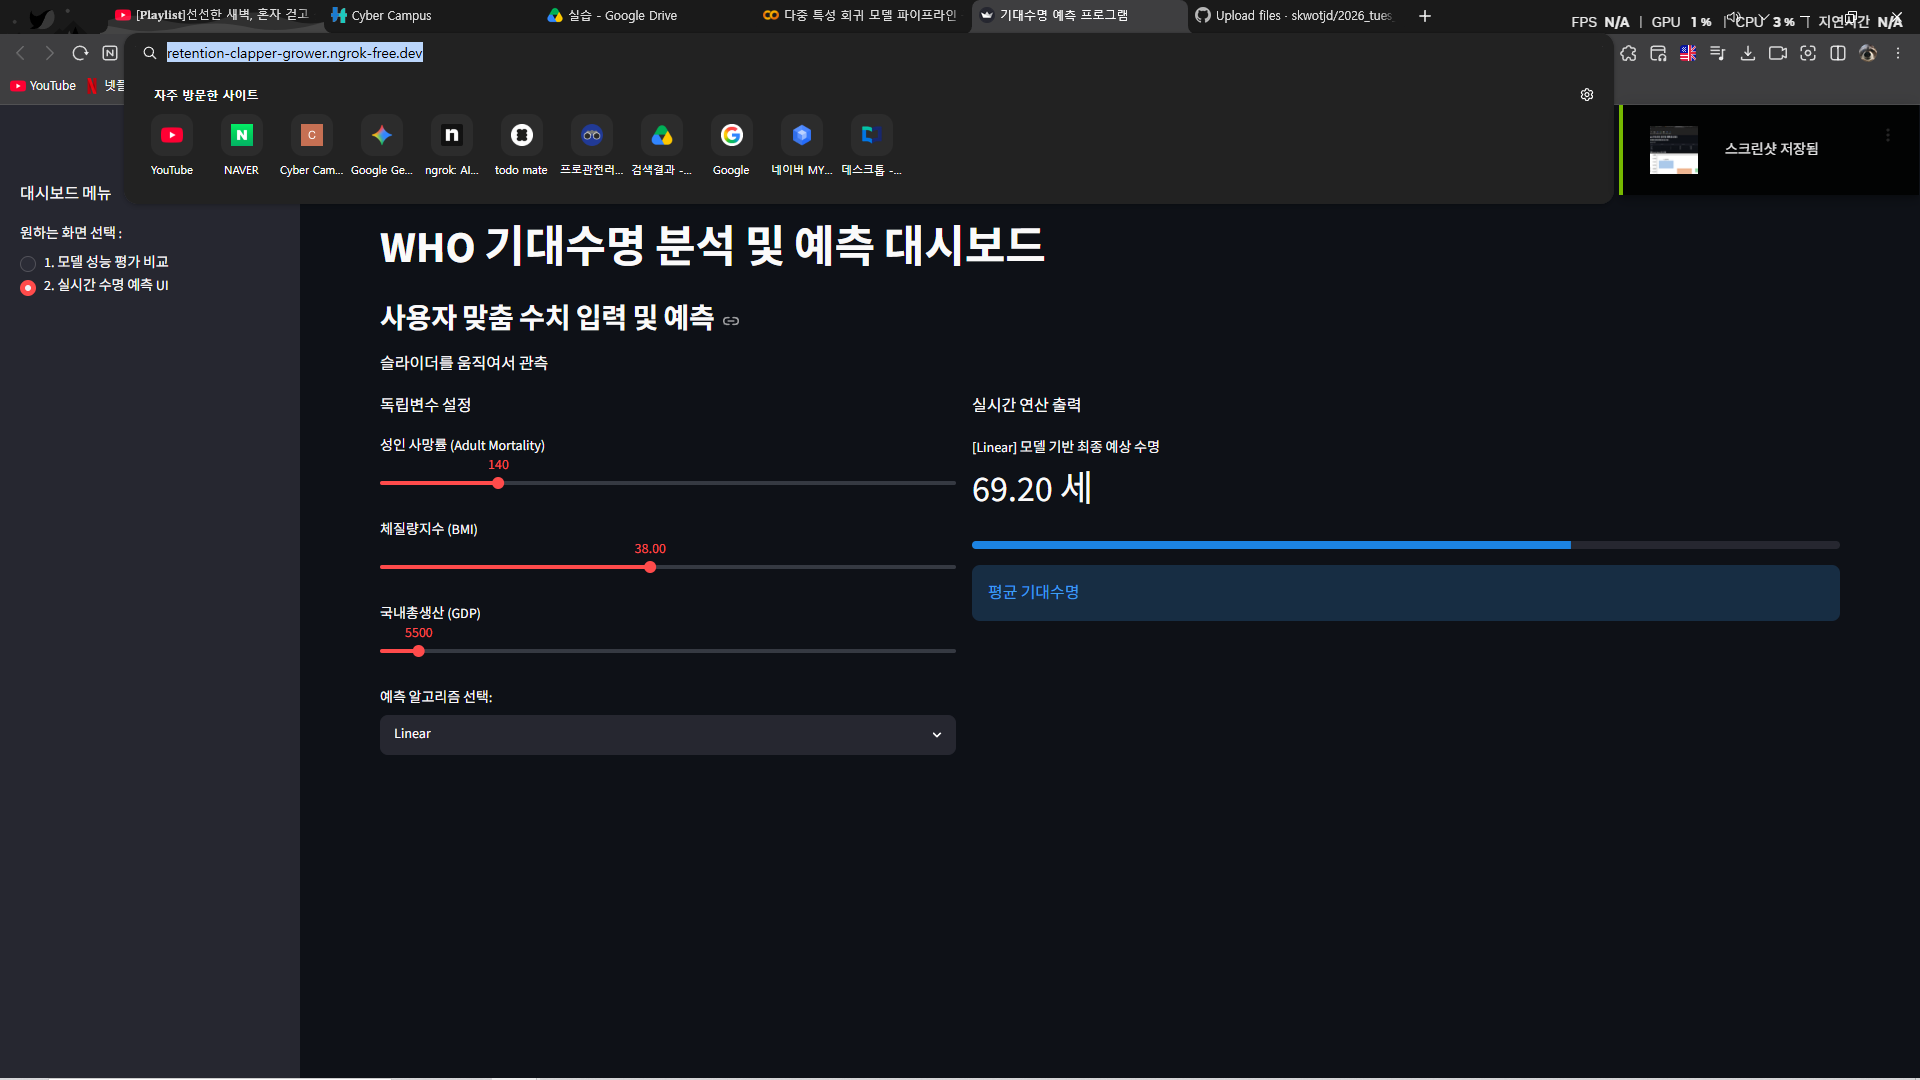